# Нейронные сети и глубокое обучение, МНАД ВШЭ

## Домашнее задание 3. Генеративные модели.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

## Warning: домашнее задание несколько муторное, потому что требуется обучить 4 типа моделей. Но в то же время оно простое, поэтому проблем с написанием кода возникнуть не должно.

# Введение

## MAGIC – Major Atmospheric Gamma Imaging Cherenkov Telescope

MAGIC (Major Atmospheric Gamma Imaging Cherenkov) - это система, состоящая из двух черенковских телескопов диаметром 17 м. Они предназначены для наблюдения гамма-лучей от галактических и внегалактических источников в диапазоне очень высоких энергий (от 30 ГэВ до 100 ТэВ).

Телескопами MAGIC в настоящее время управляют около 165 астрофизиков из 24 организаций и консорциумов из 12 стран. MAGIC позволил открыть и исследовать новые классы источников гамма-излучения, таких как, например, пульсары и гамма-всплески (GRB).

<center><img src="img/magic1.jpg" width="1000"></center>

Источник: https://magic.mpp.mpg.de/

Youtube video: https://youtu.be/mjcDSR2vSU8

## Частицы из космоса

Космические частицы, $\gamma$-кванты (фотоны) и адроны (протоны), взаимодействуют с атмосферой и порождают ливни вторичных частиц. Двигаясь с околосветовой скоростью, эти частицы излучают Черенковское излучение. Телескопы фотографируют это излучение. По фотографиям можно определить тип частицы из космоса: фотон или протон.

<center><img src="img/shower.jpg" width="500"></center>

## Фотографии

Задача атмосферного черенковского телескопа - получить изображение ливня путем измерения черенковского света от частиц ливня. Это изображение представляет собой геометрическую проекцию ливня на детектор. Для анализа этих изображений были введены параметры изображения или так называемые параметры Хилласа. Есть два вида параметров изображения: параметры формы и параметры ориентации. (Источник: http://ihp-lx.ethz.ch/Stamet/magic/parameters.html)

<center><img src="img/geo.jpg" width="400"></center>

## Фотоны vs адронов

Изображения для $\gamma$-квантов (фотонов) и адронов (протонов) отличаются по форме кластеров. Астрономы используют модели машинного обучения для классификации этих изображений. Для обучения моделей ученые искусственно генерируют такие изображения для каждого типа частиц с помощью сложных физических симуляторов.


<center><img src="img/gamma_p.png" width="600"></center>

## Ускорение симуляции

Сложные физические симуляторы требуют больших вычислительных ресурсов. Они моделируют прилет частиц из космоса, их взаимодействие с атмосферой, рождение ливней, черенковского излучения и работы телескопов для получения изображений. Но мы можем использовать генеративно-состязательные сети для быстрой симуляции!

In [1]:
!pip install diffusers

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from diffusers import DDPMScheduler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset

# Данные

Будем использовать данные телескопа MAGIC из UCI репозитория https://archive.ics.uci.edu/ml/datasets/MAGIC+Gamma+Telescope. Каждый объект в данных - параметры одного изображения кластера и метка этого кластера (фотон или адрон):


0. Length: major axis of ellipse [mm]
1. Width: minor axis of ellipse [mm]
2. Size: 10-log of sum of content of all pixels [in #phot]
3. Conc: ratio of sum of two highest pixels over fSize [ratio]
4. Conc1: ratio of highest pixel over fSize [ratio]
5. Asym: distance from highest pixel to center, projected onto major axis [mm]
6. M3Long: 3rd root of third moment along major axis [mm]
7. M3Trans: 3rd root of third moment along minor axis [mm]
8. Alpha: angle of major axis with vector to origin [deg]
9. Dist: distance from origin to center of ellipse [mm]
10. class: g,h # gamma (signal), hadron (background)

In [3]:
# read data
names = np.array(
    [
        "Length",
        "Width",
        "Size",
        "Conc",
        "Conc1",
        "Asym",
        "M3Long",
        "M3Trans",
        "Alpha",
        "Dist",
        "class",
    ]
)
data = pd.read_csv("magic04.data", header=None)
data.columns = names
data.head()

,Length,Width,Size,Conc,Conc1,Asym,M3Long,M3Trans,Alpha,Dist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


# Постановка задачи

Ваша задача заключается в том, чтобы с помощью генеративно-состязательных сетей научится генерировать параметры кластеров на изображениях телекопа для каждого типа частиц (фотона или адрона):

- $X$ - матрица реальных объектов, которые нужно начиться генерировать;
- $y$ - метки классов, которые будем использовать как условие при генерации.

In [4]:
# параметры кластеров на изображениях
X = data[names[:-1]].values
X = np.abs(X)

# метки классов
labels = data[names[-1]].values
y = np.ones((len(labels), 1))
y[labels == "h"] = 0

In [5]:
# примеры
X[:2]

array([[2.87967e+01, 1.60021e+01, 2.64490e+00, 3.91800e-01, 1.98200e-01,
        2.77004e+01, 2.20110e+01, 8.20270e+00, 4.00920e+01, 8.18828e+01],
       [3.16036e+01, 1.17235e+01, 2.51850e+00, 5.30300e-01, 3.77300e-01,
        2.62722e+01, 2.38238e+01, 9.95740e+00, 6.36090e+00, 2.05261e+02]])

In [6]:
# примеры
y[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

# Визуализация данных

Каждое изображение описывается 10 параметрами. Давайте построим распределения значений каждого параметра для каждого типа частиц.

In [7]:
def plot_hists(X1, X2, names, label1, label2, bins=np.linspace(-3, 3, 61)):
    plt.figure(figsize=(4 * 4, 4 * 2))
    for i in range(X1.shape[1]):
        plt.subplot(3, 4, i + 1)
        plt.hist(X1[:, i], bins=bins, alpha=0.5, label=label1, color="C0")
        plt.hist(X2[:, i], bins=bins, alpha=0.5, label=label2, color="C1")
        plt.xlabel(names[i], size=14)
        plt.legend(loc="best")
    plt.tight_layout()

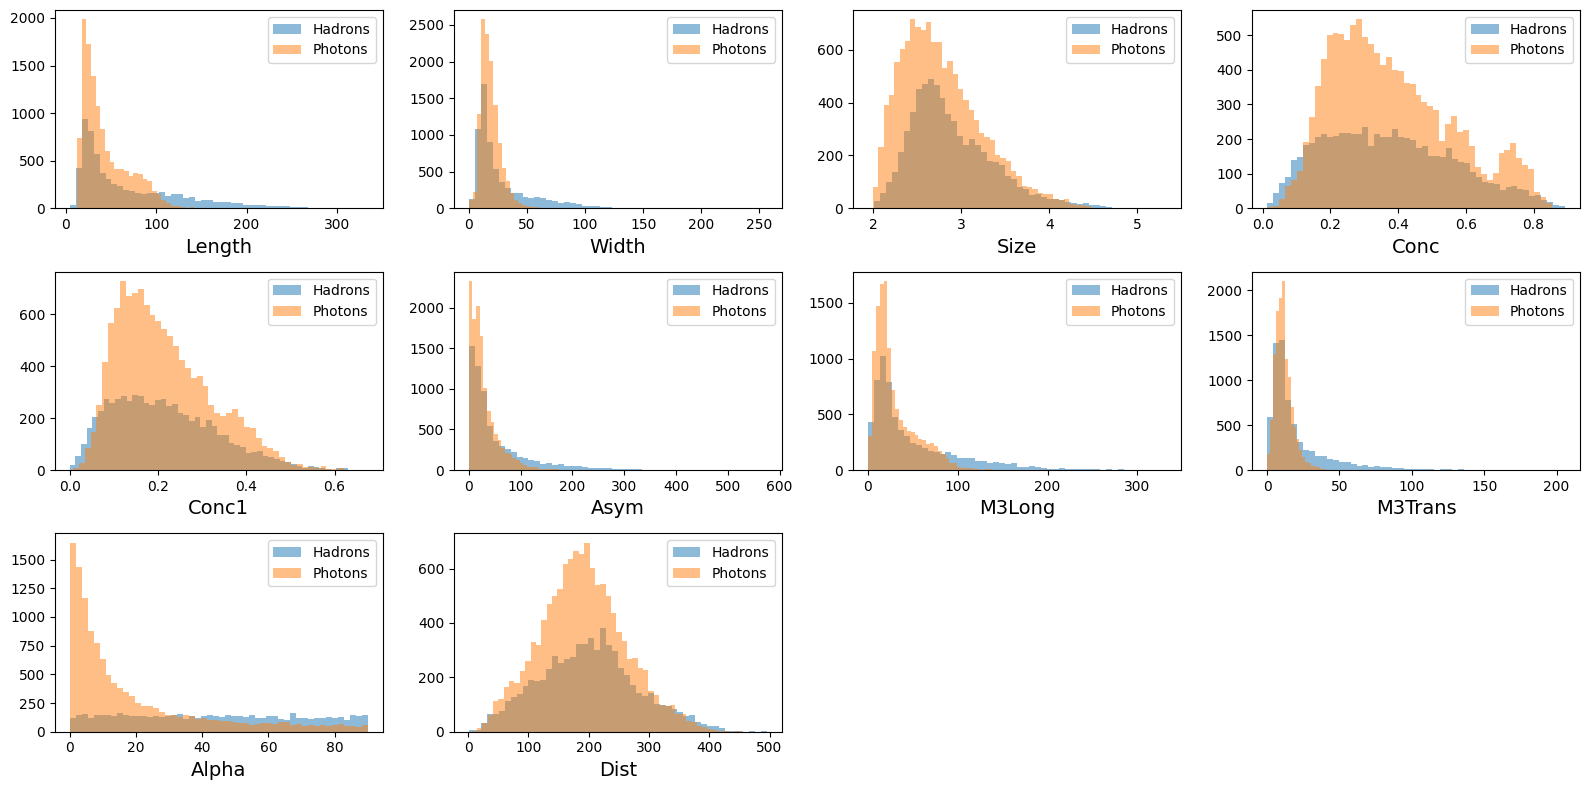

In [8]:
plot_hists(
    X[y[:, 0] == 0], X[y[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

# Предобработка данных

Из графика видим, что распределения для многих признаков имеют тяжелые хвосты. Это делает обучение генеративных моделей тяжелее. Поэтому, нужно как-то преобразовать данные, чтобы убрать эти тяжелые хвосты.

## Задание 1 (0.5 балла)

Используя функцию `sklearn.preprocessing.QuantileTransformer` трансформируйте входные данные `X`. Это преобразование делает так, чтобы распределение каждого параметра было нормальным. Описание функции доступно по ссылке http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html. Используйте значение параметра `output_distribution='normal'`.

In [9]:
X_qt = sklearn.preprocessing.QuantileTransformer(random_state=0, output_distribution='normal').fit_transform(X)

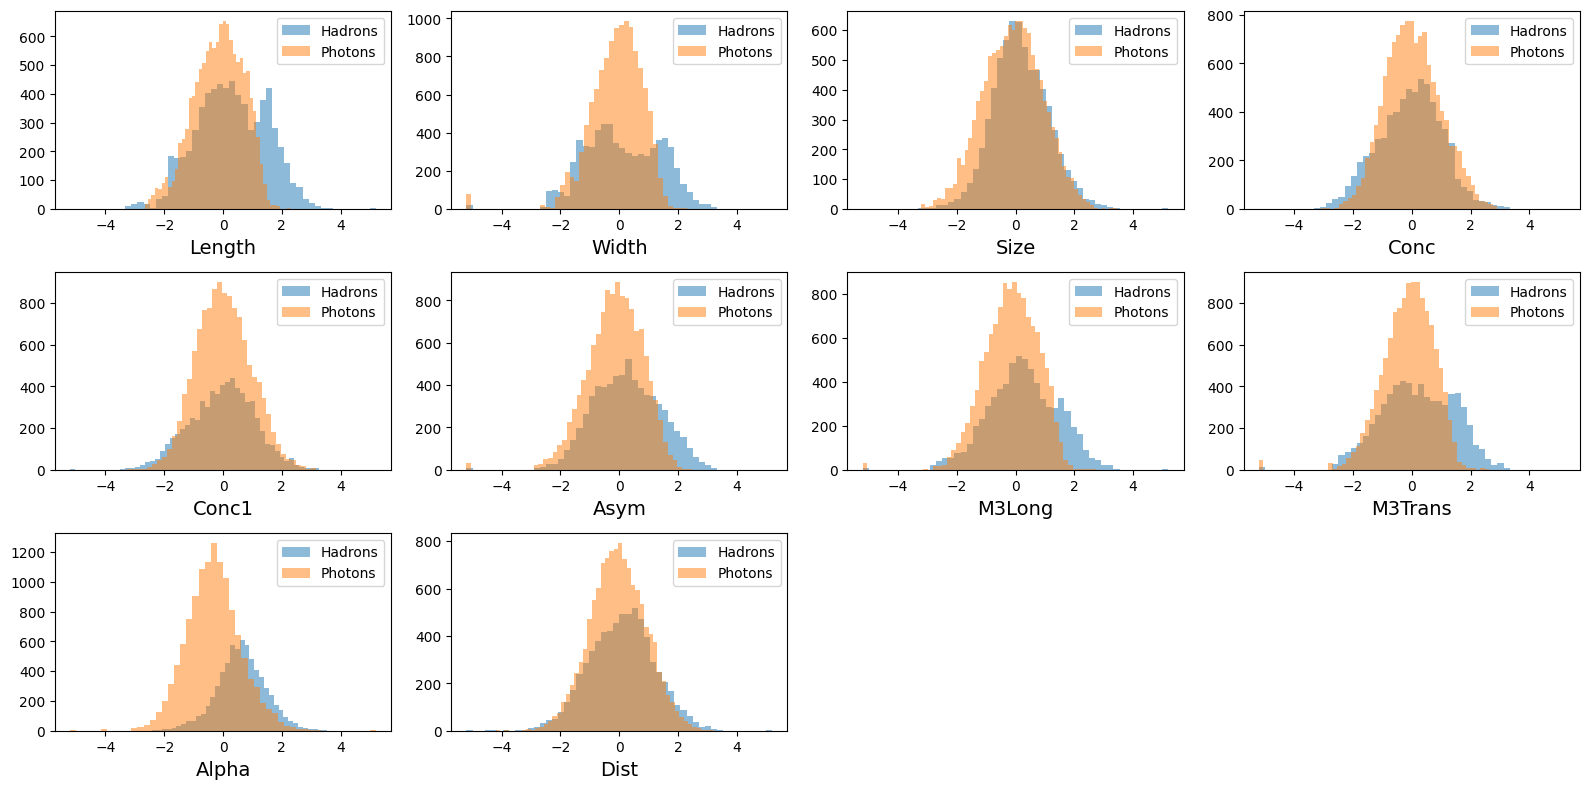

In [10]:
plot_hists(
    X_qt[y[:, 0] == 0],
    X_qt[y[:, 0] == 1],
    names,
    label1="Hadrons",
    label2="Photons",
    bins=50,
)

# Обучающая и тестовая выборки

In [11]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_qt, y, stratify=y, test_size=0.5, shuffle=True, random_state=11
)

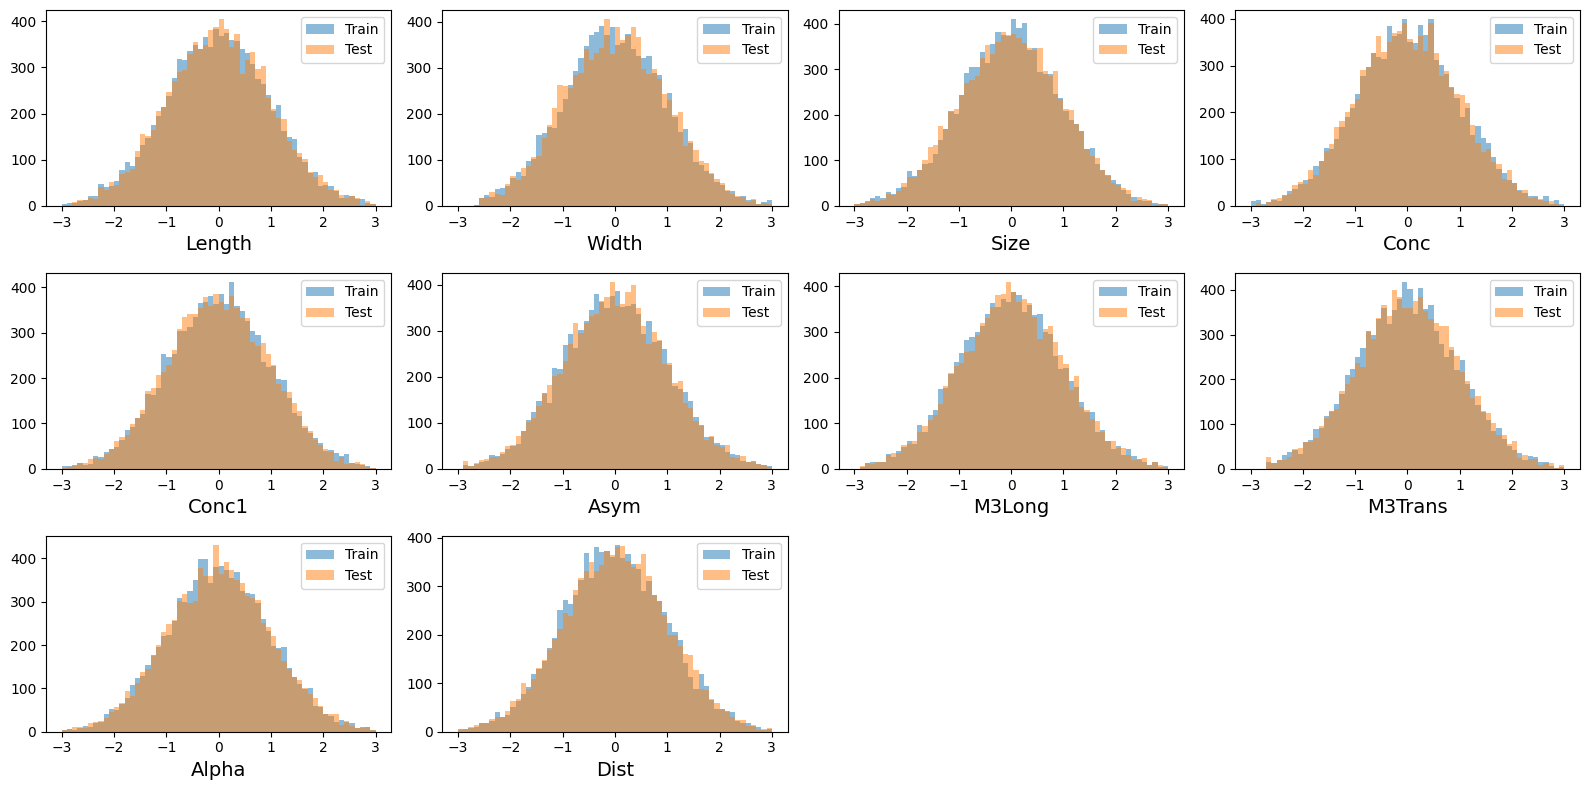

In [12]:
plot_hists(X_train, X_test, names, label1="Train", label2="Test")

# Conditional WGAN

Мы будем использовать `Conditional WGAN`, который изображен на рисунке. В качестве условия `y` мы будем использовать метку класса: **0** - адрон, **1** - фотон. Таким образом, мы будем сообщать генератору для какой частицы нужно генерировать параметры изображения.

<center><img src="img/cgan.png" width="800"></center>

Генератор $\hat{x} = G(z, y)$ будет принимать на вход шумовой вектор $z$ и вектор условий $y$, а выдавать будет сгенерированный (фейковый) вектор параметров $\hat{x}$.

Дискриминатор $D(x, y)$ будет принимать на вход вектор параметров $x$ и вектор условий $y$, а возвращать будет рациональное число.

Обучать `Conditional WGAN` будем с такой функцией потерь:

$$L(G, D) = -\frac{1}{n} \sum_{x_i \in X, y_i \in y} D(x_i, y_i) + \frac{1}{n} \sum_{z_i \in Z, y_i \in y} D(G(z_i, y_i), y_i) \to \max_G \min_D$$

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
DEVICE

device(type='cuda')

## Задание 2 (0.25 балла)

Реализуйте нейронную сеть для генератора со следующими слоями:
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

Подсказка: используйте функцию `nn.Sequential()`.

In [ ]:
class Generator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs)
        )

    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.net(zy)

## Задание 3 (0.25 балла)

Реализуйте нейронную сеть для дискриминатора со следующими слоями:
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

Подсказка: используйте функцию `nn.Sequential()`.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )

    def forward(self, x, y):
        xy = torch.cat((x, y), dim=1)
        return self.net(xy)

## Задание 4 (1 балл)

Реализуйте класс для обучения генеративной модели.

- Подсказка 1: не забывайте ограничивать веса дискриминатора. Для этого используйте `p.data.clamp_(-0.01, 0.01)`, где `p` веса дискриминатора.
- Подсказка 2: `n_critic` - число итераций обучения дискриминатора на одну итерацию обучения генератора.
- Подсказка 3: Используйте `X_tensor = torch.tensor(X_numpy, dtype=torch.float, device=DEVICE)` для перевода numpy в тензор.

In [ ]:
from tqdm import tqdm

class Fitter(object):
    def __init__(
        self,
        generator,
        discriminator,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        n_critic=5,
    ):

        self.generator = generator
        self.discriminator = discriminator
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.RMSprop(self.generator.parameters(), lr=self.lr)
        self.opt_disc = torch.optim.RMSprop(self.discriminator.parameters(), lr=self.lr)

        self.generator.to(DEVICE)
        self.discriminator.to(DEVICE)

    def fit(self, X, y):

        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        dataset_real = TensorDataset(X_real, y_cond)

        self.generator.train(True)
        self.discriminator.train(True)

        self.loss_history = []

        for epoch in tqdm(range(self.n_epochs)):
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                self.opt_disc.zero_grad()

                z = torch.normal(
                    0,
                    1,
                    (real_batch.size(0), self.latent_dim),
                    device=DEVICE,
                )

                x_fake = self.generator(z, cond_batch)

                d_real = self.discriminator(real_batch, cond_batch)
                d_fake = self.discriminator(x_fake.detach(), cond_batch)

                loss_disc = -d_real.mean() + d_fake.mean()

                loss_disc.backward()
                self.opt_disc.step()

                for p in self.discriminator.parameters():
                    p.data.clamp_(-0.01, 0.01)

                if i % self.n_critic == 0:
                    self.opt_gen.zero_grad()

                    z = torch.normal(
                        0,
                        1,
                        (real_batch.size(0), self.latent_dim),
                        device=DEVICE,
                    )
                    x_fake = self.generator(z, cond_batch)
                    d_fake = self.discriminator(x_fake, cond_batch)

                    loss_gen = -d_fake.mean()

                    loss_gen.backward()
                    self.opt_gen.step()

            Z_noise = torch.normal(0, 1, (len(X_real), self.latent_dim), device=DEVICE)
            X_fake = self.generator(Z_noise, y_cond)
            loss_epoch = torch.mean(self.discriminator(X_real, y_cond)) - torch.mean(
                self.discriminator(X_fake, y_cond)
            )
            self.loss_history.append(loss_epoch.detach().cpu())

        self.generator.train(False)
        self.discriminator.train(False)

## Обучение
Обучим модель на данных.

In [ ]:
%%time
latent_dim = 10
generator = Generator(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])
discriminator = Discriminator(n_inputs=X_train.shape[1] + y.shape[1])

fitter = Fitter(
    generator,
    discriminator,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
fitter.fit(X_train, y_train)

100%|██████████| 100/100 [01:10<00:00,  1.42it/s]

CPU times: user 1min 6s, sys: 949 ms, total: 1min 7s
Wall time: 1min 10s


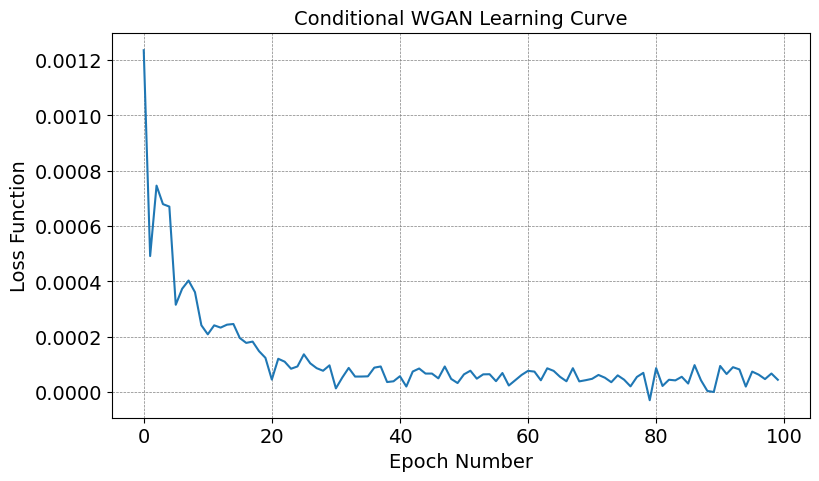

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional WGAN Learning Curve", size=14)
plt.grid(visible=True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 5 (0.5 балла)

Реализуйте функцию для генерации новый объектов $X$ по вектору условий $y$.

In [ ]:
def generate(generator, y, latent_dim):
    y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

    z = torch.normal(
        0,
        1,
        (len(y_cond), latent_dim),
        device=DEVICE,
    )

    generator.eval()
    with torch.no_grad():
        X_fake_t = generator(z, y_cond)

    X_fake = X_fake_t.detach().cpu().numpy()

    return X_fake

Теперь сгенерируем фейковые матрицы `X_fake_train` и `X_fake_test`. Сравним их с матрицами реальных объектов `X_train` и `X_test`

In [ ]:
X_fake_train = generate(fitter.generator, y_train, latent_dim)

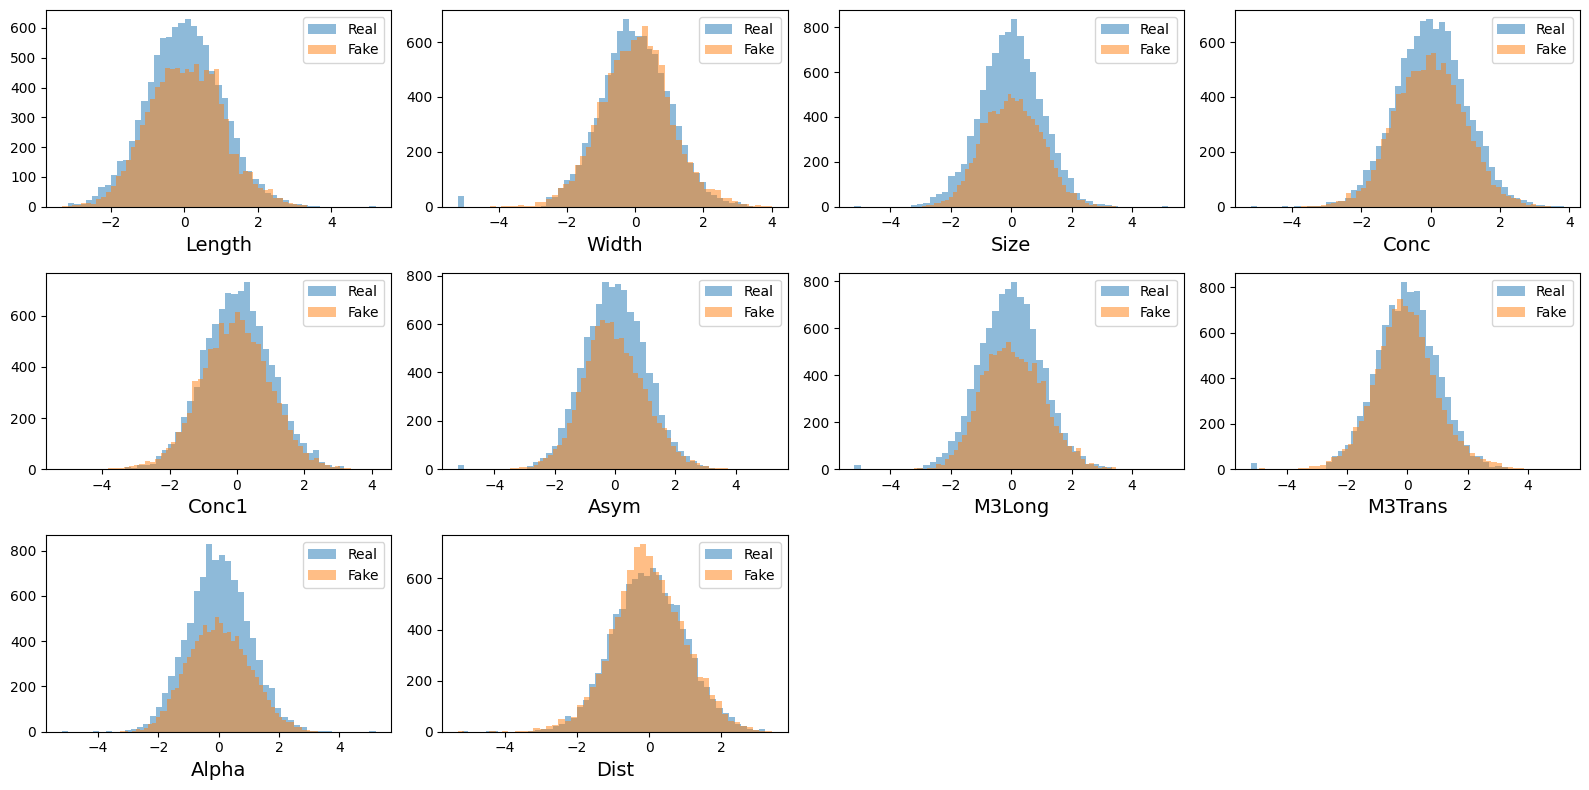

In [ ]:
plot_hists(X_train, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [ ]:
X_fake_test = generate(fitter.generator, y_test, latent_dim)

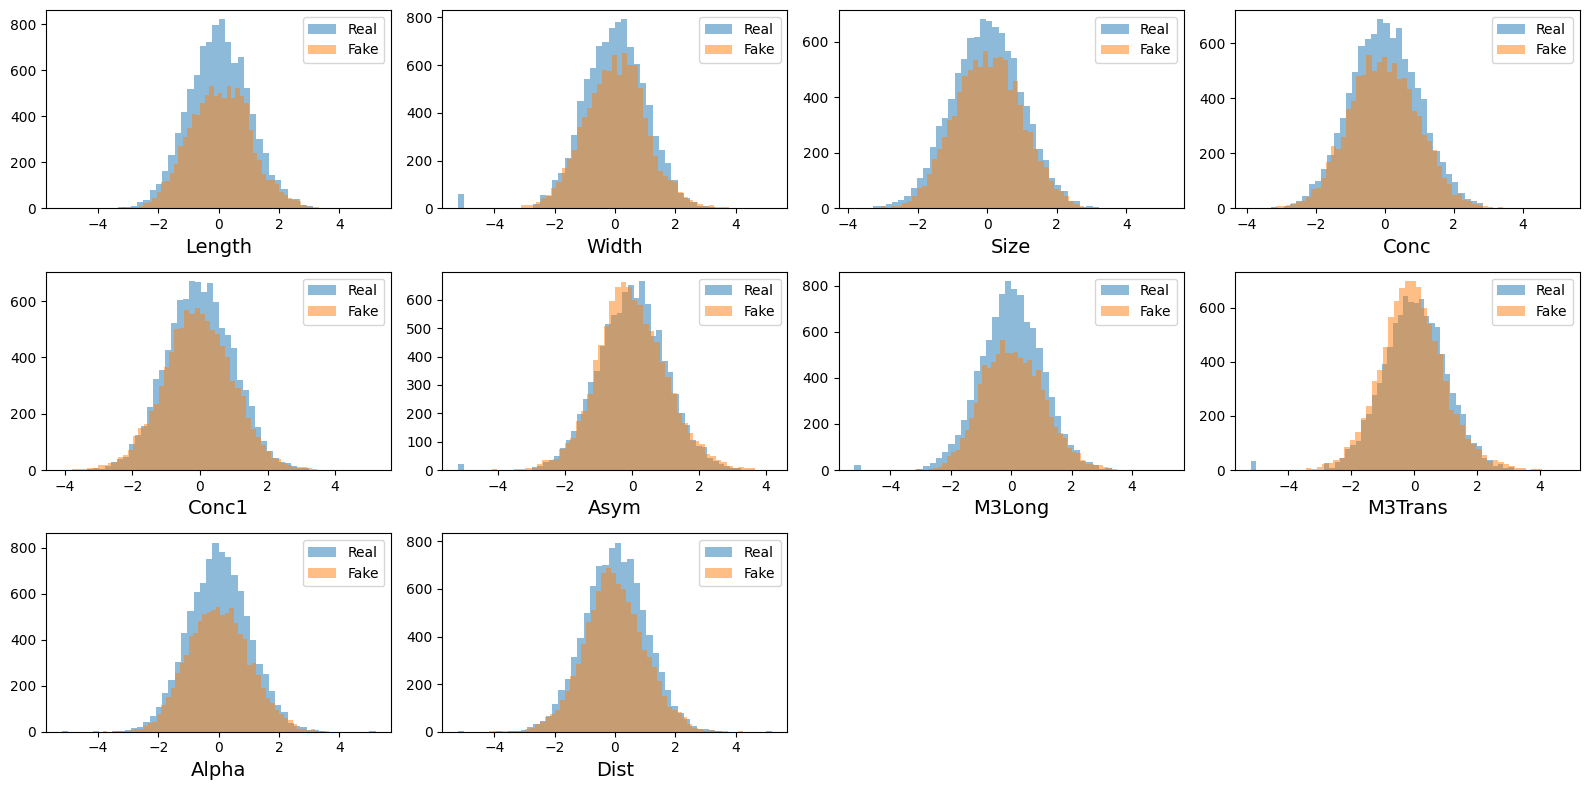

In [ ]:
plot_hists(X_test, X_fake_test, names, label1="Real", label2="Fake", bins=50)

# Измерение качества генерации

<center><img src="img/clf.png" width="600"></center>

Измерим сходство распределений внешним (подумайте почему) классификатором.

**Внешний классификатор это независимый тест, так как он внешняя модель:**

- **не участвует в обучении GAN,**

- **не получает градиенты от генератора,**

- **тренируется как обычный бинарный классификатор, различающий реальное и сгенерированное**

**Если внешний классификатор не может отличить реальные данные от фейковых, это означает, что распределения близки.**

In [ ]:
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [ ]:
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [ ]:
auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.6922722387525003


**Полученный результат говорит о том, что фейковые данные пока довольно легко отличимы от реальных.
Это ожидаемый результат при простой архитектуре. Можно взять его за базу. Модель частично научилась имитировать распределение, но ещё далека от идеала.**

# Условные вариационные автокодировщики

<center><img src="img/cvae.svg" width="600"></center>

Теперь, решим эту же задачу используя условный автокодировщик (CVAE).

## Задание 6 (0.5 балла)

Реализуйте нейронную сеть для энкодера со следующими слоями:
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой для mu; Выходной слой для log_sigma;

Подсказка: используйте функцию `nn.Sequential()`.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, n_inputs, lat_size):
        super().__init__()

        self.enc_net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
        )

        self.mu = nn.Linear(100, lat_size)
        self.log_sigma = nn.Linear(100, lat_size)

    def forward(self, x, y):
        z = torch.cat((x, y), dim=1)
        z = self.enc_net(z)
        mu = self.mu(z)
        log_sigma = self.log_sigma(z)
        return mu, log_sigma


## Задание 7 (0.5 балла)

Реализуйте нейронную сеть для декодера со следующими слоями:
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

Подсказка: используйте функцию `nn.Sequential()`.

In [ ]:
class Decoder(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        self.dec_net = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, n_outputs)
        )

    def forward(self, z, y):
        z_cond = torch.cat((z, y), dim=1)
        x_rec = self.dec_net(z_cond)
        return x_rec


## Задание 8 (0.5 балл)

Реализуйте класс для обучения вариационного автокодировщика.

In [ ]:
class VAEFitter:
    def __init__(
        self,
        encoder,
        decoder,
        batch_size=32,
        n_epochs=10,
        latent_dim=1,
        lr=0.0001,
        KL_weight=0.001,
    ):

        self.encoder = encoder
        self.decoder = decoder
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.KL_weight = KL_weight

        self.criterion = nn.MSELoss()
        self.opt = torch.optim.RMSprop(
            list(self.encoder.parameters()) + list(self.decoder.parameters()),
            lr=self.lr,
        )

        self.encoder.to(DEVICE)
        self.decoder.to(DEVICE)

    def sample_z(self, mu, log_sigma):
        eps = torch.randn(mu.shape).to(DEVICE)
        return mu + torch.exp(log_sigma / 2) * eps

    def custom_loss(self, x, rec_x, mu, log_sigma):
        KL = torch.mean(
            -0.5 * torch.sum(1 + log_sigma - mu**2 - log_sigma.exp(), dim=1), dim=0
        )
        recon_loss = self.criterion(x, rec_x)
        return KL * self.KL_weight + recon_loss

    def compute_loss(self, x_batch, cond_batch):

        mu, log_sigma = self.encoder(x_batch, cond_batch)

        z = self.sample_z(mu, log_sigma)

        rec_x = self.decoder(z, cond_batch)

        loss = self.custom_loss(x_batch, rec_x, mu, log_sigma)

        return loss

    def fit(self, X, y):

        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        dataset_real = TensorDataset(X_real, y_cond)

        self.encoder.train(True)
        self.decoder.train(True)

        self.loss_history = []

        for epoch in tqdm(range(self.n_epochs)):
            for i, (x_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                loss = self.compute_loss(x_batch, cond_batch)

                self.opt.zero_grad()
                loss.backward()
                self.opt.step()

            with torch.no_grad():
                loss_epoch = self.compute_loss(X_real, y_cond)
            self.loss_history.append(loss_epoch.detach().cpu().item())

        self.encoder.train(False)
        self.decoder.train(False)

## Обучение
Обучим модель на данных.

In [ ]:
%%time

latent_dim = 10

encoder = Encoder(n_inputs=X_train.shape[1] + y.shape[1], lat_size=latent_dim)
decoder = Decoder(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])

vae_fitter = VAEFitter(
    encoder,
    decoder,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.001,
    KL_weight=0.001,
)
vae_fitter.fit(X_train, y_train)

100%|██████████| 100/100 [01:11<00:00,  1.40it/s]

CPU times: user 1min 8s, sys: 954 ms, total: 1min 9s
Wall time: 1min 11s


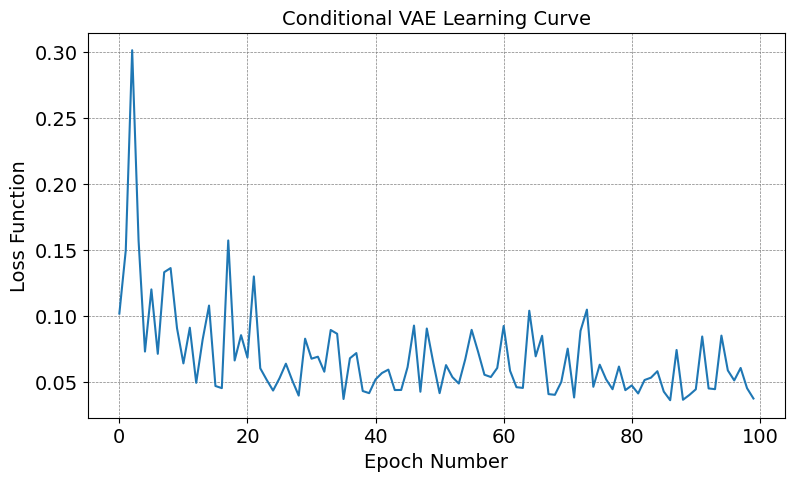

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(vae_fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional VAE Learning Curve", size=14)
plt.grid(True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 9 (0.5 балл)

Реализуйте функцию для генерации новых объектов $X$ по вектору условий $y$.

In [ ]:
def generate(decoder, y, latent_dim):

    y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

    z = torch.randn((y_cond.size(0), latent_dim), device=DEVICE)

    decoder.eval()
    with torch.no_grad():
        X_fake_t = decoder(z, y_cond)

    X_fake = X_fake_t.detach().cpu().numpy()

    return X_fake

Теперь сгенерируем фейковые матрицы `X_fake_train` и `X_fake_test`. Сравним их с матрицами реальных объектов `X_train` и `X_test`

In [ ]:
X_fake_train = generate(vae_fitter.decoder, y_train, latent_dim)

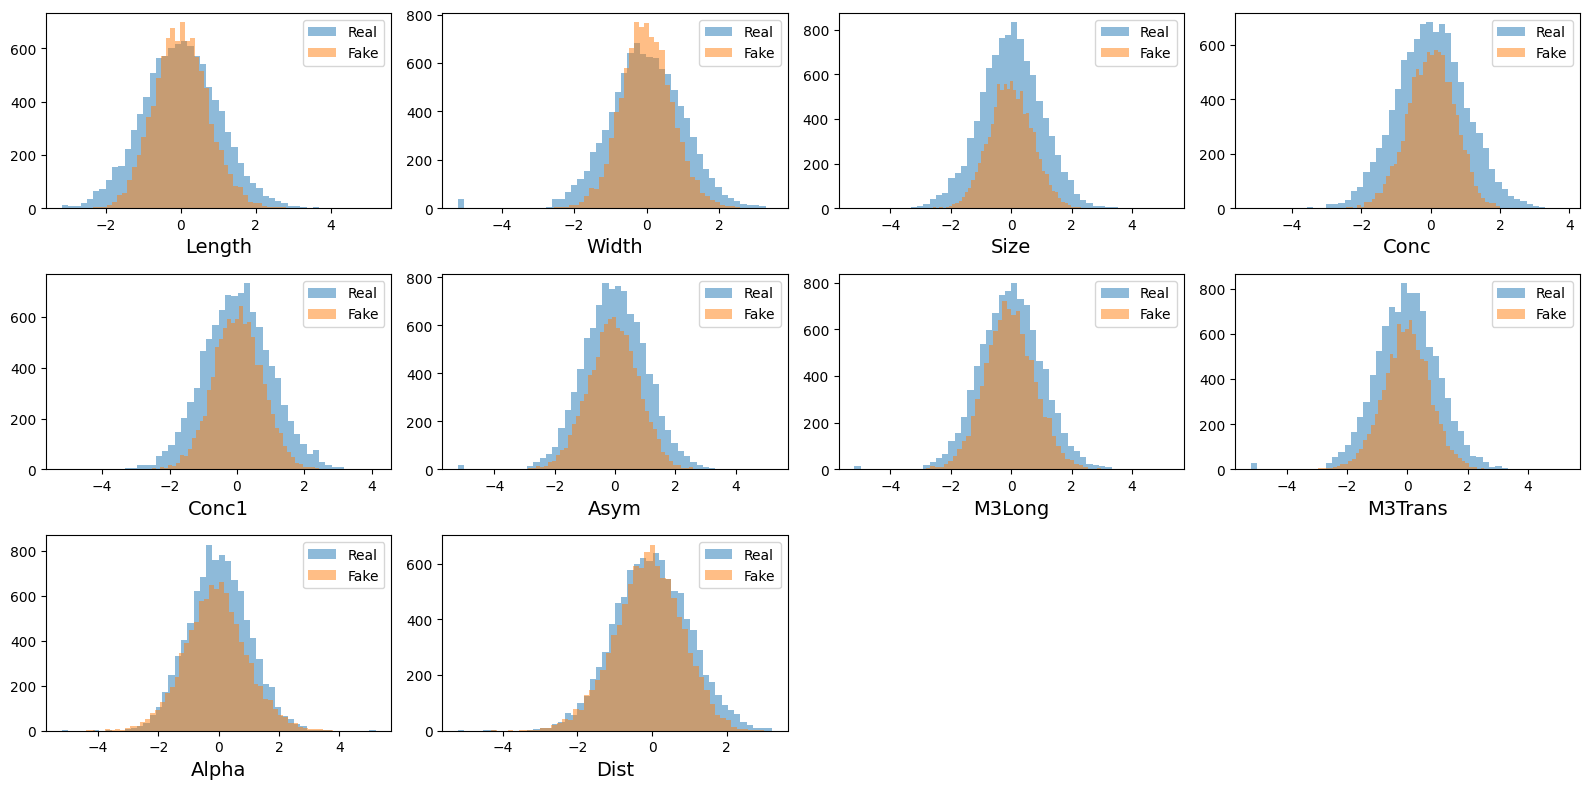

In [ ]:
plot_hists(X_train, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [ ]:
X_fake_test = generate(vae_fitter.decoder, y_test, latent_dim)

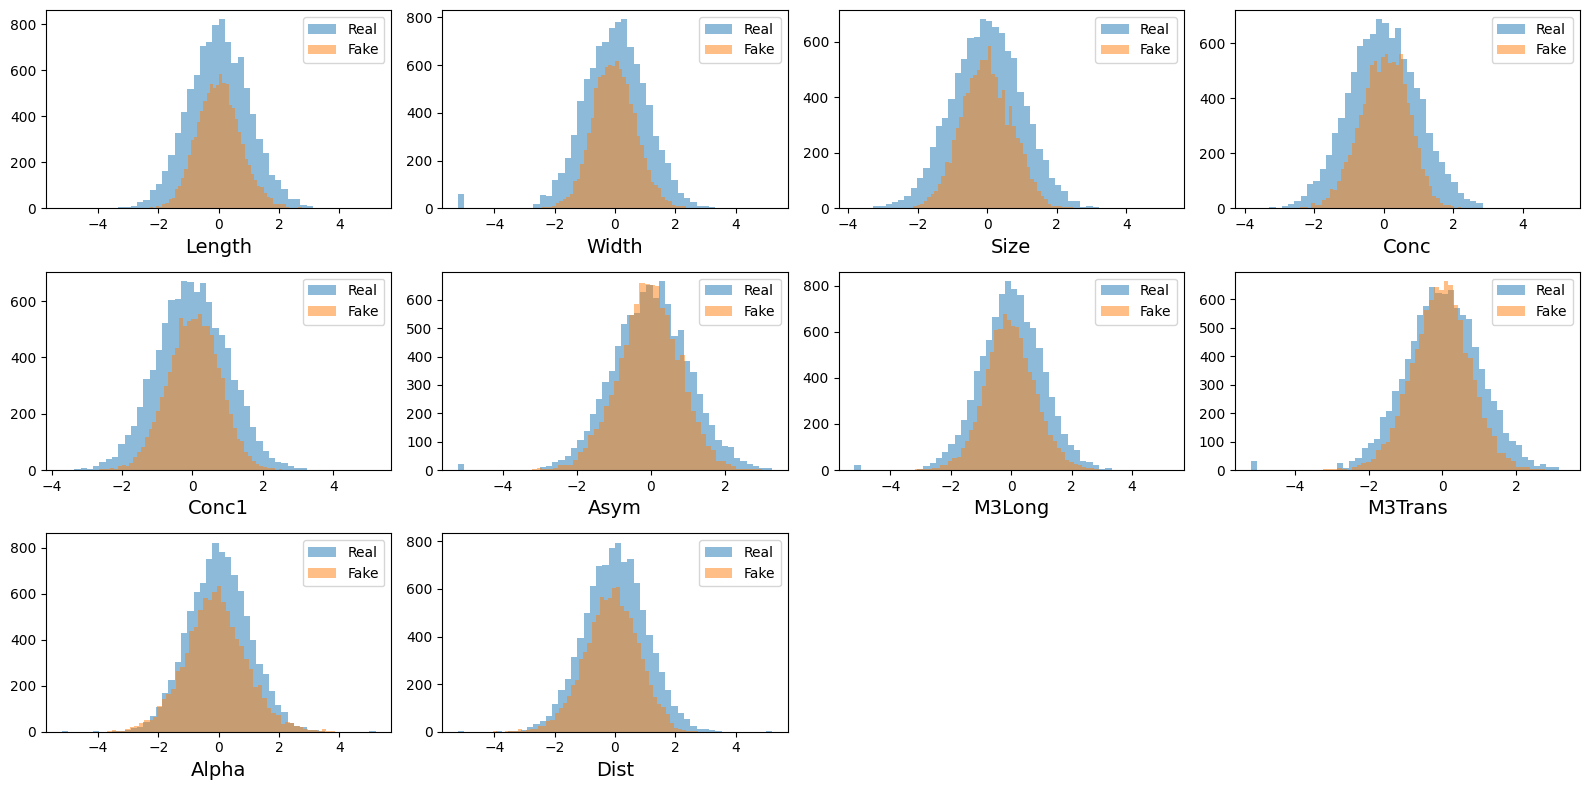

In [ ]:
plot_hists(X_test, X_fake_test, names, label1="Real", label2="Fake", bins=50)

# Измерение качества генерации

Измерим сходство распределений классификатором.

In [ ]:
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [ ]:
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.7304276200490712


**Классификатор может различить фейковые и реальные данные с хорошей уверенностью. VAE не направлен на максимальный реализм, как GAN. Его цель больше в обучении латентного представления. VAE-декодер пока не создает полностью реалистичных объектов. Модель захватила лишь часть структуры исходных данных, но оставила признаки, по которым классификатор различает два распределения.**

*Я провёл дополнительный эксперимент увеличив KL_weights до 0.01. ROC AUC составил 0.684. Это лучше чем ROC AUC = 0.692 у GAN :)*

# Диффузионные модели

Все то же самое, что и выше, но теперь диффузионки

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Задание 10 (0.5 балла)

Реализуйте фукнцию для зашумления данных, адаптировав ее под наш тип данных.

In [132]:
def corrupt(x, amount):
    noise = torch.randn_like(x)
    x_t = torch.sqrt(torch.tensor(amount)) * x + torch.sqrt(torch.tensor(1.0 - amount)) * noise
    return x_t

Совет: прочтите доку на шедулер, то как он объявлен ниже может быть неоптимально для наших данных (потому что у нас не картинки!) :)

In [133]:
NUM_DIFFUSION_STEPS = 300

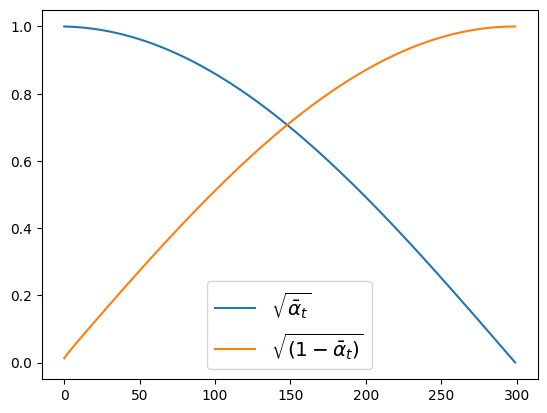

In [55]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps=300,
    beta_schedule="squaredcos_cap_v2",
    clip_sample=False,
    prediction_type="v_prediction",
    variance_type="fixed_small"
)

plt.plot(
    noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$"
)
plt.plot(
    (1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5,
    label=r"$\sqrt{(1 - \bar{\alpha}_t)}$",
)
plt.legend(fontsize="x-large");

## Задание 11 (0.5 балла)

Реализуйте нейронную сеть. В качетсве архитектуры можете взять модель генератора. В процессе экспериментов попробуйте изменять архитектуру модели для улучшения качества сгенерированных объектов.

- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

In [134]:
import torch
import torch.nn as nn

class DiffusionGenerator(nn.Module):
    def __init__(self, input_dim, condition_dim, output_dim, num_timesteps):
        super().__init__()
        self.num_timesteps = num_timesteps

        self.net = nn.Sequential(
            nn.Linear(input_dim + condition_dim + 1, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, output_dim)
        )

    def forward(self, x_t, y, t):

        t = t.float().unsqueeze(1) / self.num_timesteps
        xyt = torch.cat((x_t, y, t), dim=1)
        return self.net(xyt)

## Задание 12 (0.5 балла)

Напишите функцию для генерации нового объекта с помощью обученной модели.

In [57]:
import numpy as np

def generate_with_diffusion(model, y, latent_dim, scheduler):

    model.eval()

    if isinstance(y, np.ndarray):
        y = torch.tensor(y, dtype=torch.float32, device=DEVICE)
    else:
        y = y.to(DEVICE)

    batch_size = y.shape[0]
    x = torch.randn((batch_size, latent_dim), device=DEVICE)

    scheduler.set_timesteps(scheduler.config.num_train_timesteps)

    for t in tqdm(scheduler.timesteps, desc="Sampling", leave=False):
        t_batch = torch.full((batch_size,), t, device=DEVICE, dtype=torch.long)

        with torch.no_grad():
            v_pred = model(x, y, t_batch)

        x = scheduler.step(v_pred, t, x).prev_sample

    return x.cpu().numpy()

## Задание 13 (1 балла)

Напишите класс обучения диффузионной модели и обучите модель, после чего опишите полученные результаты. Вы можете изменять некоторые части кода для вашего удобства, но оставляйте в таком случаи комментарии, пожалуйста.

In [136]:
class DiffusionFitter:
    def __init__(
        self,
        model,
        batch_size=64,
        n_epochs=100,
        lr=1e-4
    ):
        self.model = model.to(DEVICE)
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.lr = lr

        self.opt_gen = torch.optim.AdamW(
            self.model.parameters(),
            lr=self.lr,
            weight_decay=1e-4
        )

        self.criterion = nn.MSELoss()

        self.noise_scheduler = DDPMScheduler(
            num_train_timesteps=NUM_DIFFUSION_STEPS,
            beta_schedule="squaredcos_cap_v2",
            clip_sample=False,
            prediction_type="v_prediction",
            variance_type="fixed_small"
        )

    def fit(self, X, y):
        X_tensor = torch.tensor(X, dtype=torch.float32, device=DEVICE)
        y_tensor = torch.tensor(y, dtype=torch.float32, device=DEVICE)

        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        self.model.train()
        self.loss_history = []

        for epoch in tqdm(range(self.n_epochs)):
            total_loss = 0.0

            for x0, cond in loader:
                self.opt_gen.zero_grad()

                batch_size = x0.size(0)

                t = torch.randint(
                    0,
                    self.noise_scheduler.config.num_train_timesteps,
                    (batch_size,),
                    device=DEVICE
                ).long()

                noise = torch.randn_like(x0)
                x_t = self.noise_scheduler.add_noise(x0, noise, t)

                v_pred = self.model(x_t, cond, t)
                v_target = self.noise_scheduler.get_velocity(x0, noise, t)

                # --- Min-SNR weighting (manual SNR) ---
                alphas_cumprod = self.noise_scheduler.alphas_cumprod.to(DEVICE)

                alpha_t = torch.sqrt(alphas_cumprod[t])          # (B,)
                snr = alpha_t**2 / (1 - alpha_t**2 + 1e-8)        # (B,)

                gamma = 5.0                                      # попробуй 1.0 / 5.0 / 10.0
                weights = torch.minimum(snr, torch.full_like(snr, gamma)) / snr
                weights = weights[:, None]                       # (B, 1)

                loss = (weights * (v_pred - v_target).pow(2)).mean()

                loss.backward()
                self.opt_gen.step()

                total_loss += loss.item() * batch_size

            avg_loss = total_loss / len(loader.dataset)
            self.loss_history.append(avg_loss)



In [145]:
%%time

model = DiffusionGenerator(
    input_dim=X_train.shape[1],
    condition_dim=y_train.shape[1],
    output_dim=X_train.shape[1],
    num_timesteps=NUM_DIFFUSION_STEPS
)

fitter = DiffusionFitter(
    model=model,
    batch_size=128,
    n_epochs=300,
    lr=1e-4
)

fitter.fit(X_train, y_train)


100%|██████████| 300/300 [01:23<00:00,  3.60it/s]

CPU times: user 1min 19s, sys: 816 ms, total: 1min 20s
Wall time: 1min 23s


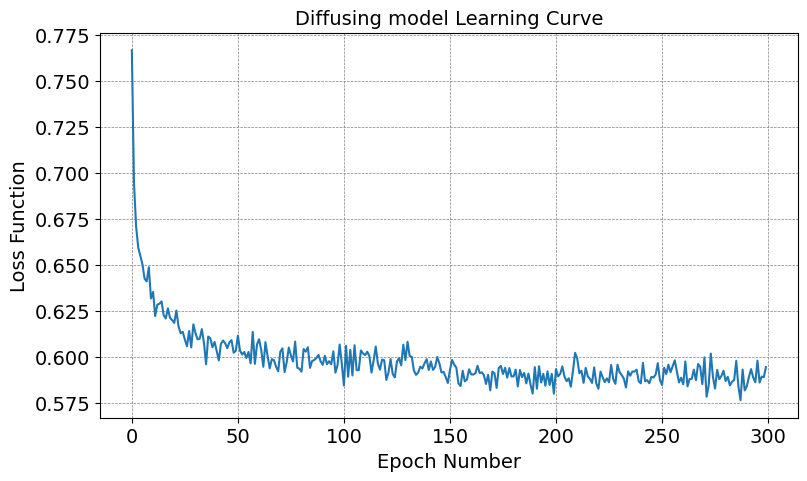

In [146]:
plt.figure(figsize=(9, 5))
plt.plot(fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Diffusing model Learning Curve", size=14)
plt.grid(True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 14 (0.5 балла)
По аналогии с прошлыми экспериментами с GAN моделью сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте метрику ROC-AUC. Какие получились результаты? Как вы их оцениваете? А в сравнении с сWGAN моделью?

In [147]:
X_fake_train = generate_with_diffusion(
    model=fitter.model,
    y=y_train,
    latent_dim=X_train.shape[1],
    scheduler=fitter.noise_scheduler
)

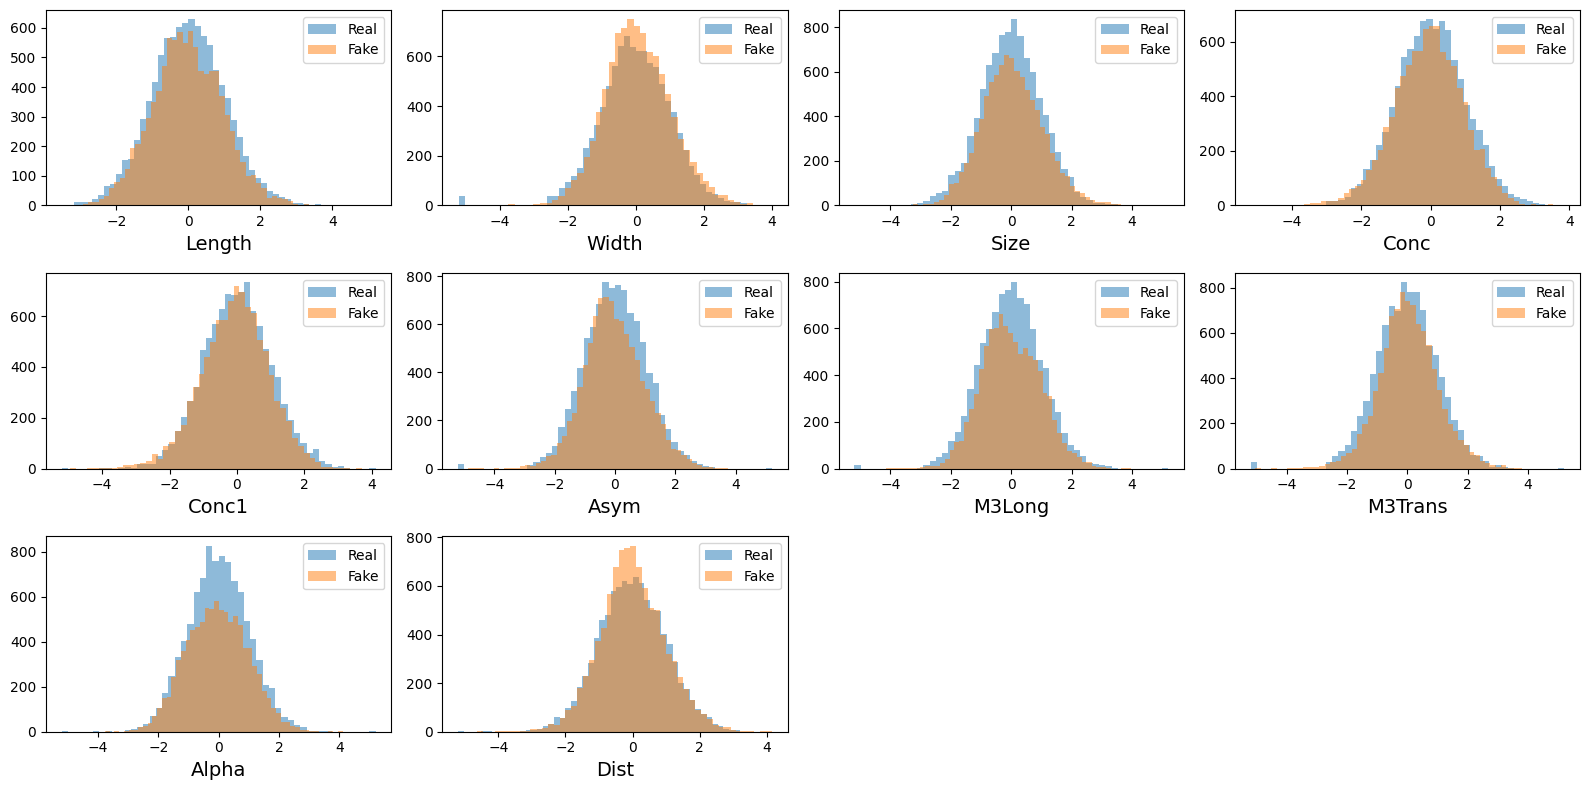

In [148]:
plot_hists(X_train, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [149]:
X_fake_test = generate_with_diffusion(
    model=fitter.model,
    y=y_test,
    latent_dim=X_train.shape[1],
    scheduler=fitter.noise_scheduler
)

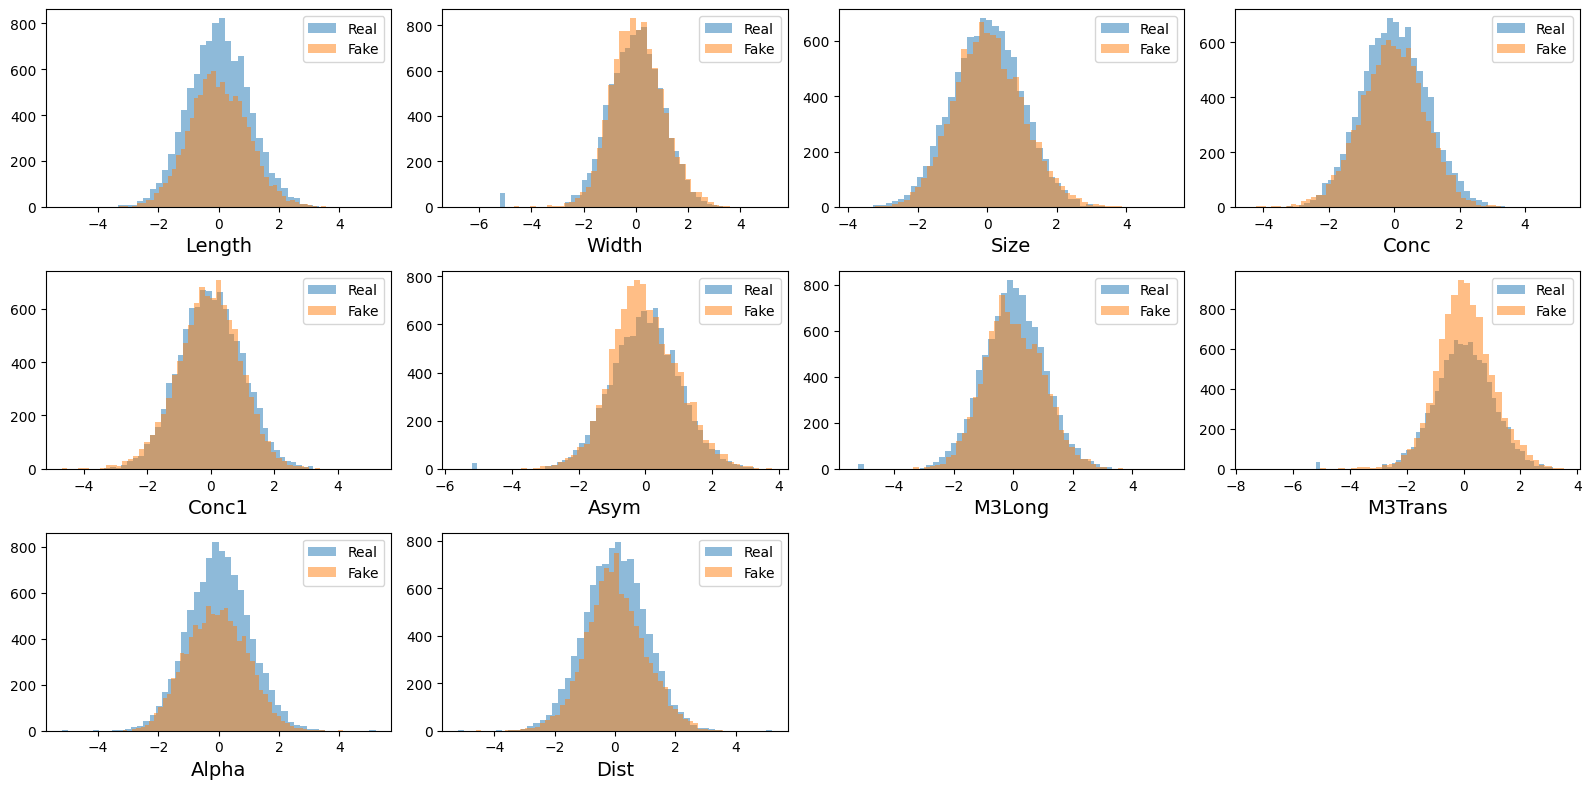

In [150]:
plot_hists(X_test, X_fake_test, names, label1="Real", label2="Fake", bins=50)

In [151]:
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [152]:
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [153]:
auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.6512136762343252


**Очень неплохой результат. Сработал лучше, чем GAN**

# Нормализационные потоки

## Задание 15 (1 балл)

Диффузия показала себя как достойный конкурент GAN модели. Так как данных не много, обучали не долго, задача не сложная - отличия от GAN не так заметны, но все равно достойные.

Попробуем обучить RealNVP для решения этой задачи.

**Дополните базовый класс необходимым.**

In [ ]:
trainloader = torch.utils.data.DataLoader(X_train, batch_size=64, shuffle=True)

In [ ]:
import torch
import torch.nn as nn

class NormalizingFlow(nn.Module):
    def __init__(self, layers, prior):
        super(NormalizingFlow, self).__init__()
        self.layers = nn.ModuleList(layers)
        self.prior = prior

    def log_prob(self, x):
        log_det_sum = 0.0
        z = x

        for layer in self.layers:
            z, log_det_jacobian = layer.f(z)
            log_det_sum += log_det_jacobian

        log_pz = self.prior.log_prob(z)

        log_px = log_pz + log_det_sum
        return log_px.mean()

    def sample(self, num_samples):

        z = self.prior.sample((num_samples,))
        x = z
        for layer in reversed(self.layers):
            x = layer.g(x)

        return x


## Задание 16 (1 балл)

Реализуйте нейронную сеть RealNVP. Возьмите для прямого и обратного преобразования нейронную сеть (функцию) со следующими параметрами:

- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

In [ ]:
import torch
import torch.nn as nn

class RealNVP(nn.Module):
    def __init__(self, var_size, mask, hidden=100):
        super(RealNVP, self).__init__()
        self.mask = mask
        self.var_size = var_size

        self.nn_t = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size)
        )

        self.nn_s = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size),
            nn.Tanh()
        )

    def f(self, x):
        x_masked = x * self.mask

        s = self.nn_s(x_masked) * (1 - self.mask)
        t = self.nn_t(x_masked) * (1 - self.mask)

        new_x = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)

        log_det = (s * (1 - self.mask)).sum(dim=1)
        return new_x, log_det

    def g(self, x):
        x_masked = x * self.mask

        s = self.nn_s(x_masked) * (1 - self.mask)
        t = self.nn_t(x_masked) * (1 - self.mask)

        new_x = x_masked + (1 - self.mask) * ((x - t) * torch.exp(-s))
        return new_x


In [ ]:
def train_nf(tr_dataloader, nf, opt, num_epochs):
    nf.train()
    loss_trace = []

    iter_i = 0

    for epoch_i in tqdm(range(num_epochs)):
        for batch in tr_dataloader:
            x = batch.float().to(next(nf.parameters()).device)

            opt.zero_grad()

            loss = -nf.log_prob(x)
            loss.backward()

            opt.step()

            loss_trace.append(loss.item())

            iter_i += 1

    return loss_trace


In [ ]:
prior = torch.distributions.MultivariateNormal(torch.zeros(10), torch.eye(10))

layers = []
for i in range(4):
    mask = ((torch.arange(10) + i) % 2).float()
    layers.append(RealNVP(var_size=10, mask=mask))

nf = NormalizingFlow(layers=layers, prior=prior)

opt = torch.optim.AdamW(nf.parameters(), lr=1e-3)

In [ ]:
loss_trace = train_nf(trainloader, nf, opt, num_epochs=100)

100%|██████████| 100/100 [01:27<00:00,  1.14it/s]


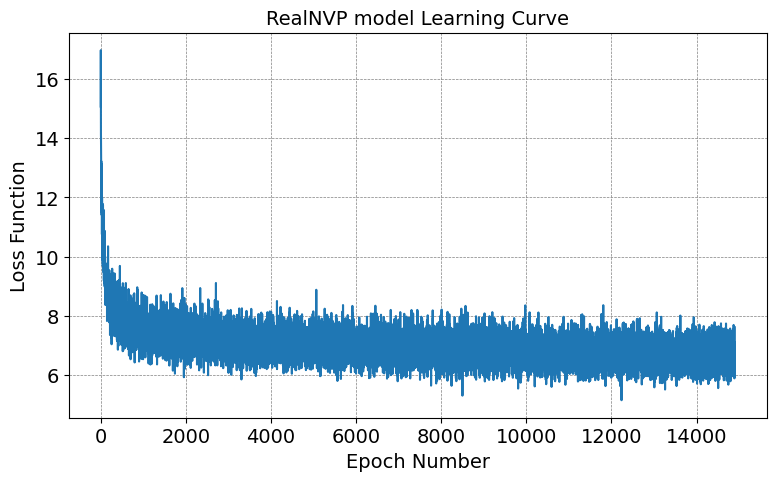

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(loss_trace)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("RealNVP model Learning Curve", size=14)
plt.grid(True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 17 (0.5 балла)

По аналогии с прошлым экспериментом с диффузией сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте ROC-AUC. Какие получились результаты? Как вы их оцениваете? А в сравнении с остальными моделями?

In [ ]:
nf.eval()
X_fake_train = nf.sample(len(X_train)).detach().cpu().numpy()

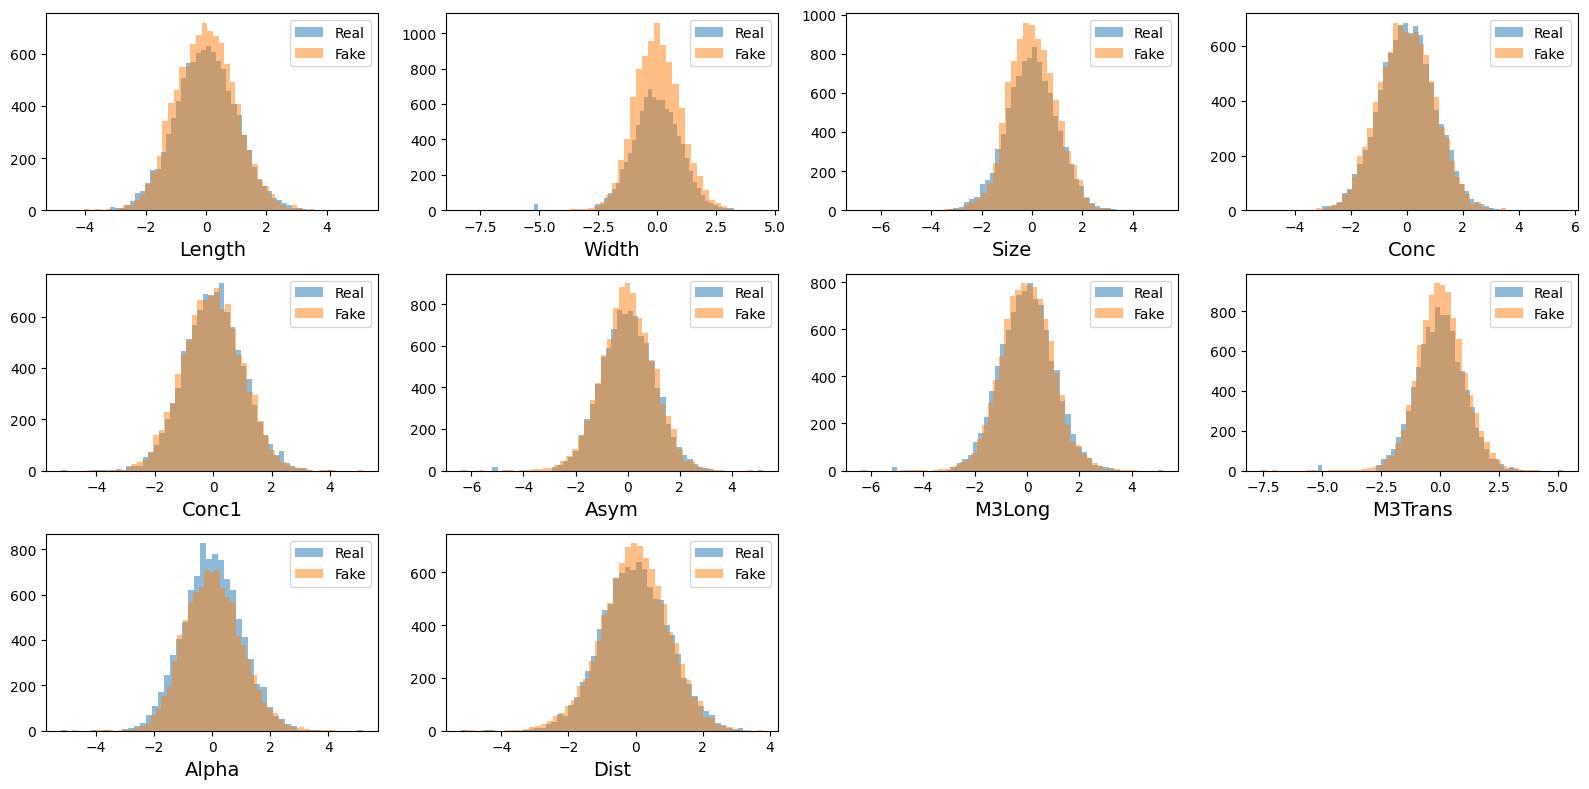

In [ ]:
plot_hists(X_train, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [ ]:
X_fake_test = nf.sample(len(X_test)).detach().cpu().numpy()

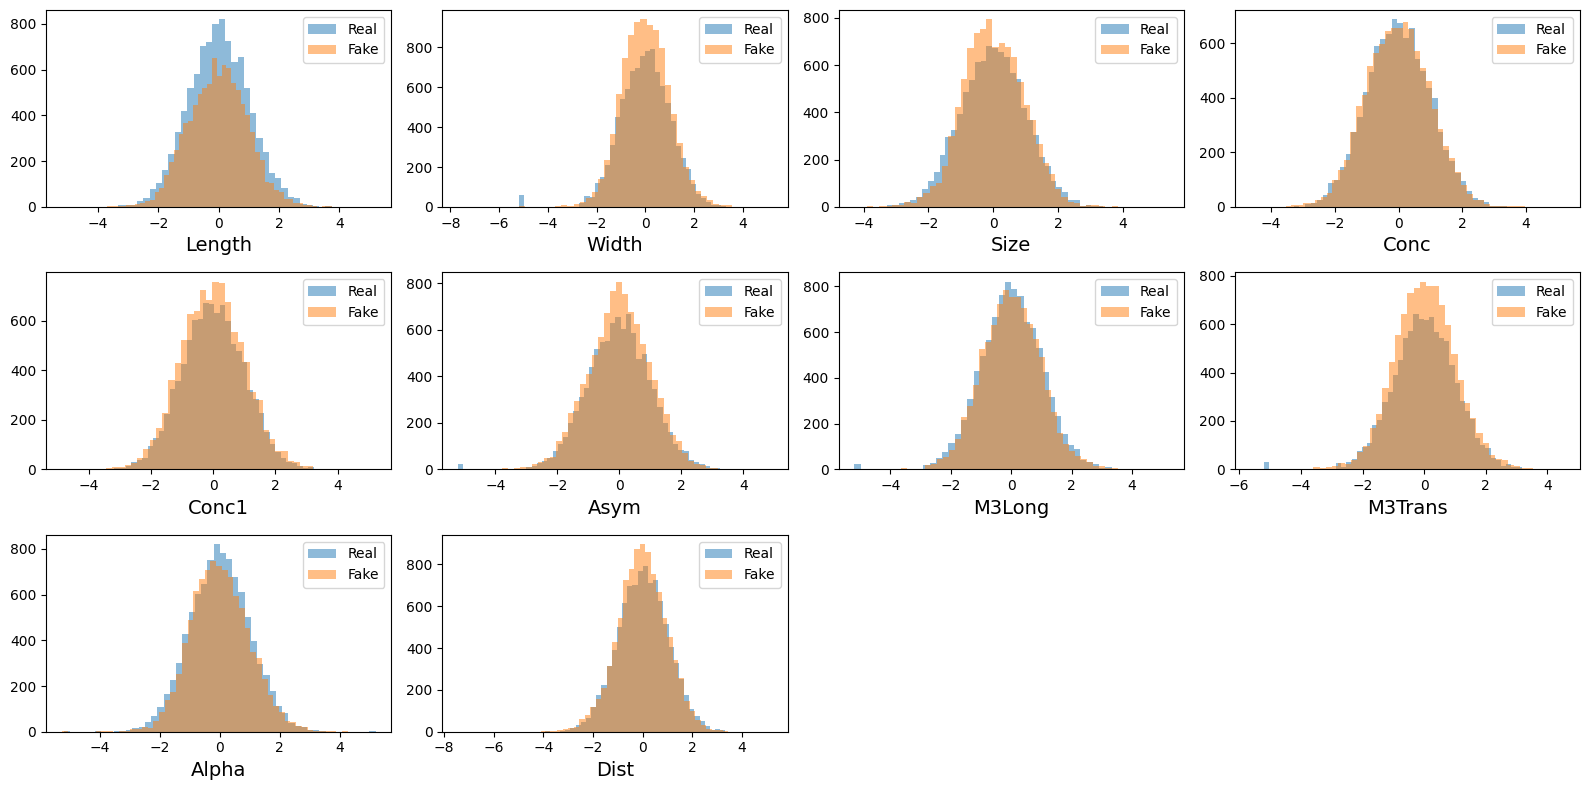

In [ ]:
plot_hists(X_test, X_fake_test, names, label1="Real", label2="Fake", bins=50)

In [ ]:
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [ ]:
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

yy_test_proba = clf.predict_proba(XX_test)[:, 1]

In [ ]:
auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.6166129294416968


**Пока что это лучший результат из всех. И лучше ожидаемого (видимо) ROC-AUC=0.65 :D**

# Улучшения (1+ балл)

Попробуйте настроить параметры обучения какой-нибудь модели или еще как-нибудь их улучшить, чтобы получить как можно меньший ROC AUC. Что получилось? Какая модель лучше?

Ставим 0.1 балл за каждую сотую скора сверх (сниз) ROC-AUC=0.65 невключительно. Т.е. за 0.65 получаете 0, за 0.649 -- 0.1, 0.639 -- 0.2, 0.609 -- 0.5, 0.559 -- 1

Как известно, в бинарной классификации круче 0.5 добиться нельзя.

In [ ]:
class RealNVP(nn.Module):
    def __init__(self, var_size, mask, hidden=200):
        super(RealNVP, self).__init__()
        self.mask = mask
        self.var_size = var_size

        self.nn_t = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size)
        )

        self.nn_s = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size),
            nn.Tanh()
        )

    def f(self, x):
        x_masked = x * self.mask

        s = self.nn_s(x_masked) * (1 - self.mask)
        t = self.nn_t(x_masked) * (1 - self.mask)

        new_x = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)
        log_det = (s * (1 - self.mask)).sum(dim=1)
        return new_x, log_det

    def g(self, z):
        z_masked = z * self.mask

        s = self.nn_s(z_masked) * (1 - self.mask)
        t = self.nn_t(z_masked) * (1 - self.mask)

        x = z_masked + (1 - self.mask) * ((z - t) * torch.exp(-s))
        return x

In [ ]:
class NormalizingFlow(nn.Module):
    def __init__(self, layers, prior):
        super(NormalizingFlow, self).__init__()
        self.layers = nn.ModuleList(layers)
        self.prior = prior

    def log_prob(self, x):
        log_det_sum = 0.0
        z = x

        for layer in self.layers:
            z, log_det = layer.f(z)
            log_det_sum += log_det

        log_pz = self.prior.log_prob(z)
        return (log_pz + log_det_sum).mean()

    def sample(self, num_samples):
        z = self.prior.sample((num_samples,))
        x = z
        for layer in reversed(self.layers):
            x = layer.g(x)
        return x


In [ ]:
def train_nf(dataloader, nf, optimizer, scheduler, num_epochs):
    nf.train()
    loss_trace = []
    pbar = tqdm(range(num_epochs))
    for epoch in pbar:
        epoch_loss = 0.0
        for batch in dataloader:
            x = batch.float().to(next(nf.parameters()).device)

            optimizer.zero_grad()
            loss = -nf.log_prob(x)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        loss_trace.append(epoch_loss)
        pbar.set_postfix({'loss': f'{epoch_loss:.3f}'})
    return loss_trace


In [ ]:
dim = X_train.shape[1]
device = DEVICE

num_flows = 8
layers = []
for i in range(num_flows):
    mask = ((torch.arange(dim) + i) % 2).float().to(device)
    layers.append(RealNVP(var_size=dim, mask=mask))

prior = torch.distributions.MultivariateNormal(
    torch.zeros(dim).to(device),
    torch.eye(dim).to(device)
)

nf = NormalizingFlow(layers, prior).to(device)

opt = torch.optim.AdamW(nf.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.5)

loss_trace = train_nf(trainloader, nf, opt, scheduler, num_epochs=500)


100%|██████████| 500/500 [15:52<00:00,  1.90s/it, loss=747.517]


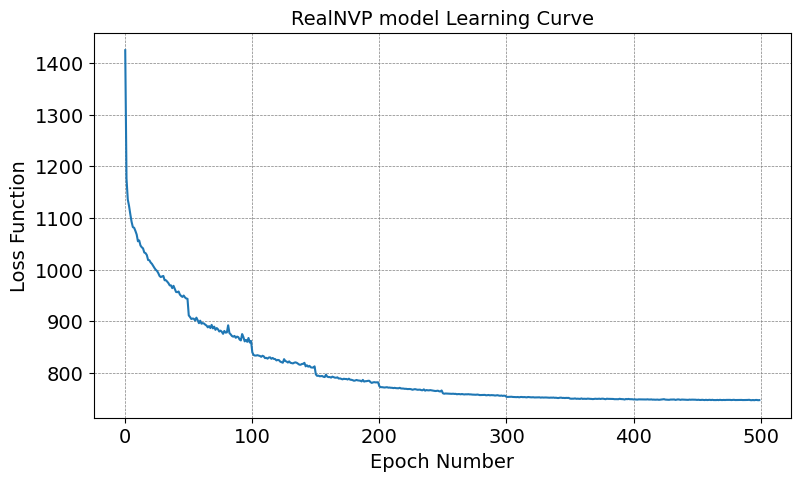

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(loss_trace)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("RealNVP model Learning Curve", size=14)
plt.grid(True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

In [ ]:
nf.eval()
X_fake_train = nf.sample(len(X_train)).detach().cpu().numpy()
X_fake_test = nf.sample(len(X_test)).detach().cpu().numpy()

XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

yy_test_proba = clf.predict_proba(XX_test)[:, 1]

auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.5722848603661429


**Было увеличено вдвое количество потоков num_flows = 8, введен переменный шаг (через 50 эпох сокращение lr вдвое), количество эпох увеличено до 500.**

**Уменьшение ROC AUC на 0.65 - 0.5722 = 0.0778**

In [ ]:
0.65 - 0.5722

0.07779999999999998